# Training application model

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
from anomaly_detection.parser.data_parsers import parse_system
from anomaly_detection.transformers import system_transformer

c:\Users\hp\AppData\Local\pypoetry\Cache\virtualenvs\anomaly-detection-mxkT3iGB-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Path to the data
project_folder = Path.cwd().parent

output_path = project_folder / "data/training/system"

system_evtx_path = project_folder / "data/raw/93_syslog.evtx"

system_evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_syslog.evtx')

# Data preparation

In [3]:
system_training_records = parse_system(system_evtx_path)

system_training_records[0]

{'EventRecordID': 210478,
 'timestamp': {'hour_cos': np.float64(0.5000000000000001),
  'month_sin': np.float64(1.0),
  'day_sin': np.float64(-0.433883739117558),
  'deltatime': Timedelta('0 days 00:02:19.046309'),
  'day_cos': np.float64(-0.9009688679024191),
  'minute_cos': np.float64(0.9781476007338057),
  'second_cos': np.float64(0.20791169081775943),
  'minute_sin': np.float64(-0.20791169081775898),
  'hour_sin': np.float64(0.8660254037844386),
  'second_sin': np.float64(-0.9781476007338056),
  'month_cos': np.float64(6.123233995736766e-17)},
 'profile': {'version': 0,
  'previous_event_id': 7036,
  'event_id': 7036,
  'correlation_activity_id': None,
  'execution_thread_id': 5368,
  'event_record_id': 210478,
  'event_id_frequency': np.float64(0.9060706937218755)},
 'data': {'old_value': None,
  'context': None,
  'status': 'en cours d’exécution',
  'process_name': None,
  'actor': None,
  'session_id': None,
  'entity': 'Service de transfert intelligent en arrière-plan',
  'new_v

In [4]:
flat_system_training_record = [{**record['timestamp'], **record['profile'], **record['data']} for record in system_training_records]

flat_system_training_record[0]

{'hour_cos': np.float64(0.5000000000000001),
 'month_sin': np.float64(1.0),
 'day_sin': np.float64(-0.433883739117558),
 'deltatime': Timedelta('0 days 00:02:19.046309'),
 'day_cos': np.float64(-0.9009688679024191),
 'minute_cos': np.float64(0.9781476007338057),
 'second_cos': np.float64(0.20791169081775943),
 'minute_sin': np.float64(-0.20791169081775898),
 'hour_sin': np.float64(0.8660254037844386),
 'second_sin': np.float64(-0.9781476007338056),
 'month_cos': np.float64(6.123233995736766e-17),
 'version': 0,
 'previous_event_id': 7036,
 'event_id': 7036,
 'correlation_activity_id': None,
 'execution_thread_id': 5368,
 'event_record_id': 210478,
 'event_id_frequency': np.float64(0.9060706937218755),
 'old_value': None,
 'context': None,
 'status': 'en cours d’exécution',
 'process_name': None,
 'actor': None,
 'session_id': None,
 'entity': 'Service de transfert intelligent en arrière-plan',
 'new_value': None}

In [5]:
system_training_df = pd.DataFrame(flat_system_training_record)

system_training_df.head(10)

,hour_cos,month_sin,day_sin,deltatime,day_cos,minute_cos,second_cos,minute_sin,hour_sin,second_sin,...,event_record_id,event_id_frequency,old_value,context,status,process_name,actor,session_id,entity,new_value
0,0.500000,1.0,-0.433884,0 days 00:02:19.046309,-0.900969,0.978148,0.207912,-0.207912,0.866025,-0.978148,...,210478,0.906071,None,None,en cours d’exécution,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,None
1,0.500000,1.0,-0.433884,0 days 00:00:00.031244,-0.900969,0.978148,0.207912,-0.207912,0.866025,-0.978148,...,210479,0.077569,Démarrage à la demande,None,None,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage automatique
2,0.500000,1.0,-0.433884,0 days 00:00:00.328128,-0.900969,0.978148,0.207912,-0.207912,0.866025,-0.978148,...,210480,0.906071,None,None,en cours d’exécution,NaN,NaN,NaN,Carte de performance WMI,None
3,0.258819,1.0,-0.433884,0 days 00:02:00.756168,-0.900969,1.000000,0.309017,0.000000,0.965926,-0.951057,...,210481,0.906071,None,None,arrêté,NaN,NaN,NaN,Carte de performance WMI,None
4,0.258819,1.0,-0.433884,0 days 00:02:00.011128,-0.900969,0.978148,0.309017,0.207912,0.965926,-0.951057,...,210482,0.077569,Démarrage automatique,None,None,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage à la demande
5,0.258819,1.0,-0.433884,0 days 00:00:00.031255,-0.900969,0.978148,0.309017,0.207912,0.965926,-0.951057,...,210483,0.906071,None,None,arrêté,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,None
6,0.258819,1.0,-0.433884,0 days 00:07:14.224809,-0.900969,0.500000,0.978148,0.866025,0.965926,0.207912,...,210484,0.906071,None,None,en cours d’exécution,NaN,NaN,NaN,Service de licences de client (ClipSVC),None
7,0.258819,1.0,-0.433884,0 days 00:00:00.109375,-0.900969,0.500000,0.978148,0.866025,0.965926,0.207912,...,210485,0.906071,None,None,en cours d’exécution,NaN,NaN,NaN,Assistant Connexion avec un compte Microsoft,None
8,0.258819,1.0,-0.433884,0 days 00:00:00.047848,-0.900969,0.500000,0.978148,0.866025,0.965926,0.207912,...,210486,0.906071,None,None,en cours d’exécution,NaN,NaN,NaN,Optimisation de livraison,None
9,0.258819,1.0,-0.433884,0 days 00:00:01.063972,-0.900969,0.500000,0.951057,0.866025,0.965926,0.309017,...,210487,0.906071,None,None,en cours d’exécution,NaN,NaN,NaN,Service de déploiement AppX (AppXSVC),None


In [6]:
X_system = system_transformer.fit_transform(system_training_df)

X_system[0]

array([ 1.39046309e+02,             nan,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.00000000e+00,  0.00000000e+00,  5.00000000e-01,  1.00000000e+00,
       -4.33883739e-01, -9.00968868e-01,  9.78147601e-01,  2.07911691e-01,
       -2.07911691e-01,  8.66025404e-01, -9.78147601e-01,  6.12323400e-17,
        0.00000000e+00,  7.03600000e+03,  7.03600000e+03,  5.36800000e+03,
        2.10478000e+05,  9.06070694e-01,             nan])

In [7]:
X_system = np.nan_to_num(X_system)

X_system[0]

array([ 1.39046309e+02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.00000000e+00,  0.00000000e+00,  5.00000000e-01,  1.00000000e+00,
       -4.33883739e-01, -9.00968868e-01,  9.78147601e-01,  2.07911691e-01,
       -2.07911691e-01,  8.66025404e-01, -9.78147601e-01,  6.12323400e-17,
        0.00000000e+00,  7.03600000e+03,  7.03600000e+03,  5.36800000e+03,
        2.10478000e+05,  9.06070694e-01,  0.00000000e+00])

In [8]:
np.savetxt(output_path / "system_features.csv", X_system, delimiter=",", fmt='%.18e')

In [9]:
X_system = np.loadtxt(output_path / "system_features.csv", delimiter=",")

In [10]:
pd.DataFrame(X_system).describe().T

,count,mean,std,min,25%,50%,75%,max
0,59779.0,139.046310,234.847775,0.000000e+00,1.108008,6.328229e+01,126.089500,2.592166e+03
1,59779.0,0.005955,0.237642,0.000000e+00,0.000000,0.000000e+00,0.000000,1.200000e+01
2,59779.0,0.079694,0.270820,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
3,59779.0,0.000636,0.025205,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
4,59779.0,0.001489,0.038557,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
5,59779.0,0.077569,0.267494,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
6,59779.0,0.000368,0.019181,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
7,59779.0,0.999632,0.019181,0.000000e+00,1.000000,1.000000e+00,1.000000,1.000000e+00
8,59779.0,0.000351,0.018740,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
9,59779.0,0.003279,0.057167,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00


# Modeling

In [11]:
from sklearn.ensemble import IsolationForest

system_model = IsolationForest(
    n_estimators=512,
    contamination=0.093,
    max_features=0.5,
    max_samples=512,
    n_jobs=-1,
)

system_model.fit(X_system)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",512
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",512
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.093
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",0.5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ax_features=1)


In [12]:
scores = system_model.score_samples(X_system)
predictions = system_model.predict(X_system)

In [13]:
results_df = system_training_df.copy()

results_df["anomaly_score"] = scores
results_df["prediction"] = predictions

results_df.head()

,hour_cos,month_sin,day_sin,deltatime,day_cos,minute_cos,second_cos,minute_sin,hour_sin,second_sin,...,old_value,context,status,process_name,actor,session_id,entity,new_value,anomaly_score,prediction
0,0.500000,1.0,-0.433884,0 days 00:02:19.046309,-0.900969,0.978148,0.207912,-0.207912,0.866025,-0.978148,...,None,None,en cours d’exécution,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,None,-0.483095,1
1,0.500000,1.0,-0.433884,0 days 00:00:00.031244,-0.900969,0.978148,0.207912,-0.207912,0.866025,-0.978148,...,Démarrage à la demande,None,None,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage automatique,-0.608324,-1
2,0.500000,1.0,-0.433884,0 days 00:00:00.328128,-0.900969,0.978148,0.207912,-0.207912,0.866025,-0.978148,...,None,None,en cours d’exécution,NaN,NaN,NaN,Carte de performance WMI,None,-0.504699,1
3,0.258819,1.0,-0.433884,0 days 00:02:00.756168,-0.900969,1.000000,0.309017,0.000000,0.965926,-0.951057,...,None,None,arrêté,NaN,NaN,NaN,Carte de performance WMI,None,-0.485089,1
4,0.258819,1.0,-0.433884,0 days 00:02:00.011128,-0.900969,0.978148,0.309017,0.207912,0.965926,-0.951057,...,Démarrage automatique,None,None,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage à la demande,-0.613472,-1


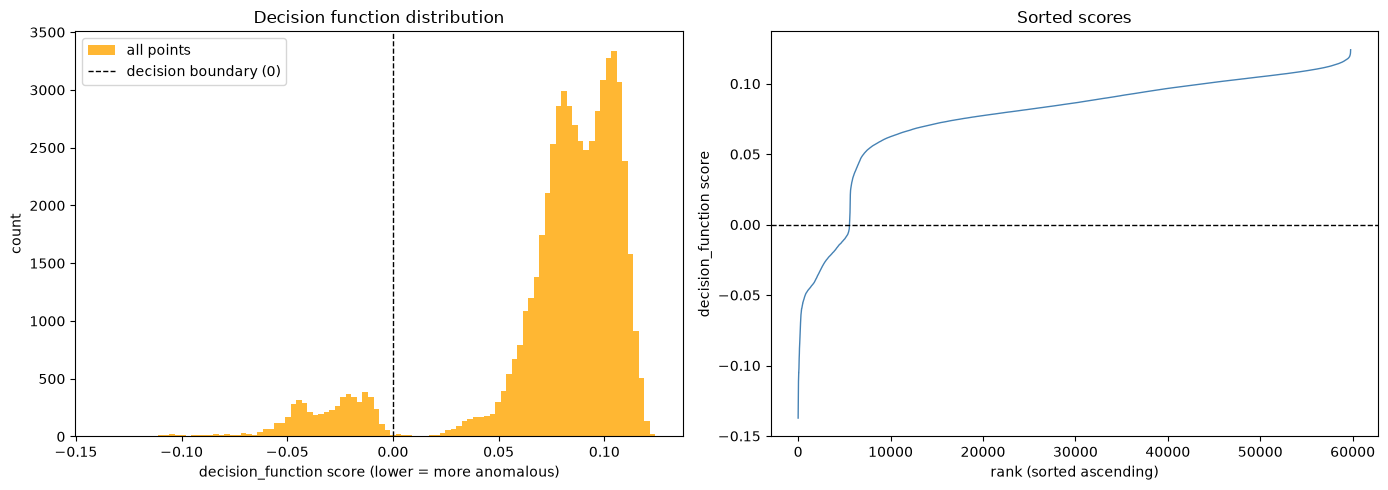

n points               : 59779
score min / max         : -0.1373 / 0.1241
score mean / std        : 0.0765 / 0.0391
   0.1th percentile     : -0.1057  (59 points below)
   0.5th percentile     : -0.0645  (298 points below)
     1th percentile     : -0.0535  (597 points below)
     2th percentile     : -0.0456  (1195 points below)
     5th percentile     : -0.0257  (2988 points below)


array([ 0.07946548, -0.04576319,  0.05786193, ...,  0.06684425,
        0.06684715,  0.06718626], shape=(59779,))

In [14]:
from anomaly_detection.utils.score_diagnostics import run_diagnostics

run_diagnostics(system_model, X_system, known_anomaly_mask=None)

In [15]:
decision_scores = system_model.decision_function(X_system)

new_contamination = np.mean(decision_scores < 0.05)

new_contamination

np.float64(0.11858679469378879)

In [16]:
anomalies_df = results_df[results_df['prediction'] == -1]

anomalies_df

,hour_cos,month_sin,day_sin,deltatime,day_cos,minute_cos,second_cos,minute_sin,hour_sin,second_sin,...,old_value,context,status,process_name,actor,session_id,entity,new_value,anomaly_score,prediction
1,5.000000e-01,1.000000e+00,-0.433884,0 days 00:00:00.031244,-0.900969,0.978148,2.079117e-01,-0.207912,0.866025,-0.978148,...,Démarrage à la demande,None,None,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage automatique,-0.608324,-1
4,2.588190e-01,1.000000e+00,-0.433884,0 days 00:02:00.011128,-0.900969,0.978148,3.090170e-01,0.207912,0.965926,-0.951057,...,Démarrage automatique,None,None,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage à la demande,-0.613472,-1
29,2.588190e-01,1.000000e+00,-0.433884,0 days 00:00:00.031243,-0.900969,0.978148,2.079117e-01,-0.207912,0.965926,-0.978148,...,Démarrage à la demande,None,None,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage automatique,-0.609485,-1
32,6.123234e-17,1.000000e+00,-0.433884,0 days 00:02:00.001307,-0.900969,0.978148,3.090170e-01,0.207912,1.000000,-0.951057,...,Démarrage automatique,None,None,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage à la demande,-0.621449,-1
49,6.123234e-17,1.000000e+00,-0.433884,0 days 00:00:00.031250,-0.900969,0.978148,2.079117e-01,-0.207912,1.000000,-0.978148,...,Démarrage à la demande,None,None,NaN,NaN,NaN,Service de transfert intelligent en arrière-plan,Démarrage automatique,-0.609196,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59763,-7.071068e-01,1.224647e-16,0.974928,0 days 00:01:02.190954,-0.222521,0.309017,-8.660254e-01,-0.951057,0.707107,-0.500000,...,None,None,None,NaN,NaN,3.0,S-1-5-21-3073298170-276159943-2983424533-500,None,-0.586458,-1
59764,-7.071068e-01,1.224647e-16,0.974928,0 days 00:00:00.068370,-0.222521,0.309017,-8.660254e-01,-0.951057,0.707107,-0.500000,...,None,3,None,NaN,NaN,NaN,\??\C:\Users\Administrateur.CARTE\ntuser.dat,None,-0.626318,-1
59765,-7.071068e-01,1.224647e-16,0.974928,0 days 00:00:00.131825,-0.222521,0.309017,-8.090170e-01,-0.951057,0.707107,-0.587785,...,None,481,None,NaN,NaN,NaN,\??\C:\Users\Administrateur.CARTE\AppData\Loca...,None,-0.645990,-1
59773,-7.071068e-01,1.224647e-16,0.974928,0 days 00:00:02.583376,-0.222521,0.309017,-1.045285e-01,-0.951057,0.707107,-0.994522,...,None,3,None,NaN,NaN,NaN,\??\C:\Users\Administrateur.CARTE\AppData\Loca...,None,-0.627085,-1


In [17]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(anomalies_df['event_id'].value_counts())

event_id
7040     4637
16        152
6013      135
1801       72
55         72
6          61
1          35
15         32
12         21
35         20
98         18
6033       17
20         12
2          12
14         10
13          9
7001        9
44          8
43          7
19          7
1074        6
7002        6
6006        6
50104       6
50105       6
50106       6
51047       6
51057       6
50037       6
109         6
153         6
25          6
27          6
18          6
32          6
30          6
172         6
3           6
11          6
16962       6
16977       6
16983       6
16993       6
50036       6
50103       6
51046       6
6009        6
6005        6
6038        6
1054        6
10148       5
5823        4
1014        4
7045        4
7042        3
10149       3
8015        3
7026        1
15008       1
15007       1
10010       1
36          1
8021        1
8032        1
7023        1
Name: count, dtype: int64


In [26]:
# Extract samples from each anomalous event ID
def pick_system_samples(n_samples_per_event):
    for event_id, group in anomalies_df.groupby("event_id"):
        print(f"\n{'=' * 60}")
        print(f"EventID {event_id}  --  {len(group)} anomalous rows")
 
        idx_min, idx_max = group.index.min(), group.index.max()
        idx_span = idx_max - idx_min
        print(f"row-index range: {idx_min} -> {idx_max}  (span: {idx_span})")
        print(f"{'=' * 60}")
 
        sample = group.sort_values("anomaly_score").head(n_samples_per_event)
 
        for idx, row in sample.iterrows():
            print(f"\n  row index:        {idx}")
            print(f"  event_record_id:  {row['event_record_id']}")
            print(f"  anomaly_score:    {row['anomaly_score']:.4f}")
 
            for col in [
                "event_id",
                "previous_event_id",
                "event_id_frequency",
                "version",
                "correlation_activity_id",
                "execution_thread_id",
            ]:
                if col in row and pd.notna(row[col]):
                    val = str(row[col])[:300]
                    print(f"  {col:<16}: {val}")
            
            for col in [
                "actor",
                "process_name",
                "session_id",
                "status",
                "old_value",
                "new_value",
                "entity",
                "context",
            ]:
                if col in row and pd.notna(row[col]):
                    val = str(row[col])[:300]
                    print(f"  {col:<16}: {val}")

In [ ]:
from contextlib import redirect_stdout

with open(output_path / 'anomalous_samples.txt', 'w') as f:
    with redirect_stdout(f):
        pick_system_samples(5)